Importer les fichiers et packages

In [1]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


# Renseingner les noms des fichiers pour accéder aux données.
file_path_commandes = 'Extract ALL_ Datalake.xlsx'
file_path_archives='Extract ALL_ Archive.xlsx'
file_path_store='STORE.xlsx'


# Chargement des fichiers
df_commandes = pd.read_excel(file_path_commandes, sheet_name='KBRW_ORDER_LINE')
#df_PDL=pd.read_excel(file_path_archives,'PDP_PDL_QTY_ARCHIVE',header=None, engine='openpyxl')
df_PDL=pd.read_excel(file_path_archives,'PDP_PDL_QTY_ARCHIVE')
df_archives_forecast=pd.read_excel(file_path_archives,'ARCHIVE_FORECAST_EXPORTED_WEEK')
df_archives_besoin_distrib=pd.read_excel(file_path_archives,'AN_APP010_EXP_NEED_ARCHIVE')
df_magasins=pd.read_excel(file_path_store,sheet_name='STORE')
df_archives_visibilite = pd.read_excel(
    file_path_archives, sheet_name='AN_APP031_TO_BE_SHIPPED_ARCHIVE')



Cleaning Data


In [2]:
df=df_commandes.copy()
# Only DELIVERY_STATUS that can be processed are taken into account
# Deletion of lines whose DELIVERY_STATUS doesn't give us enough information about the status of the delivery (on time, late or early)
df = df[~df['DELIVERY_STATUS'].isin(
    ['actionrequired', 'claim','delayed', 'waitinginpickuppoint', 'waitingnextattempt', 'returnedtosender','intransit','outfordelivery'])]
# Deletion of lines with null values in DELIVERY_STATUS (no delivery status information)
df = df[~pd.isna(df['DELIVERY_STATUS'])]

# Only RDCs corresponding to those of the M46203 product are taken into account
# Loading the visibility sheet (AN_APP031_TO_BE_SHIPPED), to list all RDCs through which M46203 products transit
RDC_df = pd.read_excel(file_path_commandes, sheet_name='AN_APP031_TO_BE_SHIPPED')
# List of all RDCs through which M46203 products transit
valid_RDC = RDC_df.loc[:, "RDC"].unique()
# Keep only lines where the RDCs match those of product M46203
df = df[df['SOURCE_LOCATION'].isin(valid_RDC)]

# Only stores that match those of the M46203 product are taken into account.

# List of all stores selling M46203
valid_pickup_locations = df_magasins.loc[:, "STORE"].unique()
# Keep only lines where the stores match those of product M46203
df = df[df['PICKUP_LOCATION'].isin(valid_pickup_locations)]

# New information calculated or converted and stored in a new column
# Change of format of the different dates
df['INITIAL_EFD_MIN'] = df['INITIAL_EFD_MIN'].apply(
    lambda x: datetime.strptime(x, '%Y-%m-%d') if pd.notna(x) else pd.NaT)
df['INITIAL_EFD_MAX'] = df['INITIAL_EFD_MAX'].apply(
    lambda x: datetime.strptime(x, '%Y-%m-%d') if pd.notna(x) else pd.NaT)
# Calculation of the order date
df['ORDER_DATE'] = df.apply(lambda x: x['INITIAL_EFD_MIN'] if pd.isna(
    x['LEADTIME_MIN']) else x['INITIAL_EFD_MIN'] - pd.Timedelta(days=x['LEADTIME_MIN']), axis=1)
# Convert order date to week format (e.g. W202348)
df['ORDER_WEEK'] = 'W' + df['ORDER_DATE'].dt.year.astype(
    str) + df['ORDER_DATE'].dt.isocalendar().week.astype(str).str.zfill(2)
# Convert DELIVERY_STATUS_DATE to a date format
#df['DATE_STATUS'] = pd.to_datetime(df['DELIVERY_STATUS_DATE'].str[:4] + df['DELIVERY_STATUS_DATE'].str[5:7] + df['DELIVERY_STATUS_DATE'].str[8:10])
df['DATE_STATUS'] = pd.to_datetime(df['DELIVERY_STATUS_DATE'])

# Calculation of the delivery time based on delivery status


def calculate_delay_day(row):
  # If the order was delivered within the delivery interval, the delay is 0 (order arrived on time)
  if ((row['INITIAL_EFD_MIN'] - row['DATE_STATUS']).days <= 0) and ((row['INITIAL_EFD_MAX'] - row['DATE_STATUS']).days >= 0):
    return 0
  # Otherwise, we calculate the number of days difference to obtain the delivery time
  else:
  # If the product has been delivered after the maximum delivery date, it is overdue (positive number of days)
    if (row['INITIAL_EFD_MAX'] - row['DATE_STATUS']).days < 0:
      return (row['DATE_STATUS'] - row['INITIAL_EFD_MAX']).days
  # If the product has been delivered before the minimum delivery date, it is ahead of schedule (negative number of days)
    else:
      return (row['DATE_STATUS'] - row['INITIAL_EFD_MIN']).days



# Only take into account orders for which we have real information on delivery times
# Create a new column with the delivery time (positive if late, negative if early, 0 if on time and None if no info).
df['DELAY_DAY'] = df.apply(calculate_delay_day, axis=1)

# Convert DELAY_DAY to number of weeks
df['DELAY_WEEK'] = df['DELAY_DAY'].apply(
    lambda x: x // 7 + 1 if x > 0 else x // 7 if x < 0 else 0)

# Sheet reorganization
# Deleting unwanted columns
columns_to_drop = ['REQUEST_ID', 'LINE_ITEM_NO', 'LAST_STATUS', 'LAST_REASON_CODE', 'SKU', 'QTY', 'LAST_MODIFICATION_DATE', 'TIMESTAMP', 'LEADTIME_MIN', 'LEADTIME_MAX',
                   'OFFER', 'PRIORITIZED', 'PERSO_ID', 'SCORE', 'ORDER_TYPE', 'REVISED_EFD_MIN', 'REVISED_EFD_MAX', 'DELIVERY_STATUS_DATE', 'COLLECTION_DATE', 'ESTIMATED_DELIVERY_DATE']
df.drop(columns=columns_to_drop, inplace=True)
# New column order
columns_order = ['ORDER_ID', 'ORDER_DATE', 'ORDER_WEEK', 'SOURCE_LOCATION', 'PICKUP_LOCATION',
                 'INITIAL_EFD_MIN', 'INITIAL_EFD_MAX', 'DELIVERY_STATUS', 'DATE_STATUS', 'DELAY_DAY', 'DELAY_WEEK']
df = df[columns_order]

df_r=df.copy()

df.to_excel('Commandes_filtrees.xlsx', index=False)

Définition d'une variation de forecast pour une commande


In [3]:
def semaine_sans_w(week_string):
  # Utilisation d'une expression régulière pour extraire le numéro de semaine
  match = re.match(r'W(\d+)', week_string)
  if match:
   # Retourner le groupe correspondant au numéro de semaine
    return int(match.group(1))
  else:
       # Si aucune correspondance trouvée, retourner None ou une valeur par défaut selon votre besoin
    return None


def forecast_reel(ligne):
  j_commande=df_r.loc[ligne,'ORDER_DATE']
  j_arrivee=df_r.loc[ligne,'DATE_STATUS']
  magasin=df_r.loc[ligne,'PICKUP_LOCATION']
  semaine_commande=df_r.loc[ligne,'ORDER_WEEK']

  pays = df_magasins.loc[df_magasins['STORE'] == magasin, 'GEO_3'].iloc[0]
  region= None
  if pays =='CHINA':
    region = 'CHINA'
  elif pays in ['NORTH EUROPE','SOUTH EUROPE W/O ME']:
    region = 'EUROPE W/O MIDDLE EAST'
  elif pays == 'JAPAN':
    region= 'JAPAN'
  elif pays == 'KOREA (DOM)':
    region ='KOREA (DOM)'
  elif pays == 'LATIN AMERICA':
    region ='LATIN AMERICA'
  elif pays == 'MIDDLE EAST':
    region ='MIDDLE EAST'
  elif pays == 'NORTH ASIA':
    region ='NORTH ASIA'
  elif pays == 'SOUTH ASIA W/O KDOM':
    region ='SOUTH ASIA W/O KDOM'
  elif pays in ['CANADA','HAWAII','NORTH AMERICA W/O C AND H']:
    region ='NORTH AMERICA'

  if region is None:  #not in ['CHINA','NORTH AMERICA','SOUTH ASIA W/O KDOM','NORTH ASIA','EUROPE W/O MIDDLE EAST','JAPAN','MIDDLE EAST','LATIN AMERICA']:
    return('non calculable')

   # Mise en forme de la date
  # Convertir la chaîne en objet datetime
  j_commande_obj = datetime.utcfromtimestamp(j_commande.timestamp())
  j_arrivee_obj = datetime.utcfromtimestamp(j_arrivee.timestamp())

  # Formater la date selon le format "20231203"
  j_commande = j_commande_obj.strftime("%Y%m%d")
  j_arrivee = j_arrivee_obj.strftime("%Y%m%d")

  # Extraire le numéro de semaine
  num_semaine_a = j_arrivee_obj.strftime("%W")

  # Concaténer avec le préfixe "W" et l'année
  s_arrivee= f"W{j_arrivee_obj.year}{num_semaine_a}"
  numero_livraison=semaine_sans_w(s_arrivee)
  numero_commande=semaine_sans_w(semaine_commande)
  #Mise sous forme d'entiers pour les calculs
  j_commande = int(j_commande)
  j_arrivee = int(j_arrivee)


  df_archives_forecast['SEMAINESANSW']=df_archives_forecast['WEEK'].apply(semaine_sans_w)

  df_forecast_initial= df_archives_forecast.loc[(df_archives_forecast['FORECAST_LEVEL'] == region) &
                    (df_archives_forecast['REPORT_DATE'] == j_commande)]

  i=1
  while df_forecast_initial.empty and i<7:   #regarde si le forecast est calculé 1j avant
    df_forecast_initial= df_archives_forecast.loc[(df_archives_forecast['FORECAST_LEVEL'] == region) &
                    (df_archives_forecast['REPORT_DATE'] == j_commande-i)]
    i=i+1
  if df_forecast_initial.empty:
    return('non calculable')
  df_forecast_initial=df_forecast_initial.loc[df_forecast_initial['SEMAINESANSW']<=numero_livraison]
  #df_forcast_initial est le df avec le forecast calculé juste avant la commande pour toutes les semaines jusqu'à la livraison

  #df_forecast_reel est la dernière valeur du forecsat calculée pour chaque semaine
  qtt_reel=[]

  for semaine in range(numero_commande, numero_livraison+1):
    df_inter=df_archives_forecast.loc[(df_archives_forecast['FORECAST_LEVEL'] == region) &
                            (df_archives_forecast['SEMAINESANSW'] == semaine)]
    if df_inter.empty:
      return('non calculable')
    df_inter=df_inter.iloc[-1]
    Qtt_reel_int= df_inter.loc["QTY"]
    qtt_reel.append(Qtt_reel_int)


  var_intermediaire=[]
  ponderation=[]

  for i in range(len(qtt_reel)):
    ponderation.append(qtt_reel[i])
    var_intermediaire.append((qtt_reel[i] - df_forecast_initial.iloc[i]['QTY'])/df_forecast_initial.iloc[i]['QTY'])
  var_totale=0
  somme=sum(ponderation)
  for i in range (len(ponderation)):
    var_totale+=var_intermediaire[i]*ponderation[i]
  return(var_totale/somme)


Définition pour une variation de visibilité pour une commande

In [4]:
# Création colonne REPORT_DATE de la forme 'AAAAMMJJ' dans les archives de la visibilité
# Fonction pour formater la date
def format_date(date):
    date_obj = datetime.utcfromtimestamp(date.timestamp())
    return date_obj.strftime('%Y%m%d')


# Convertir les valeurs de la colonne 'EXTRACT_TMSTP' en objets datetime
df_archives_visibilite['EXTRACT_TMSTP'] = pd.to_datetime(
    df_archives_visibilite['EXTRACT_TMSTP'])

# Application de la fonction à la colonne EXTRACT_TMSTP
df_archives_visibilite['REPORT_DATE'] = df_archives_visibilite['EXTRACT_TMSTP'].apply(
    format_date)

# Conversion de la colonne REPORT_DATE en entier
df_archives_visibilite['REPORT_DATE'] = df_archives_visibilite['REPORT_DATE'].astype(
    int)


def visibility(ligne):
    RDC = df_r.loc[ligne, 'SOURCE_LOCATION']

    # Récupération des dates en objet datetime
    jour_commande_datetime = datetime.utcfromtimestamp(
        df_r.loc[ligne, 'ORDER_DATE'].timestamp())
    jour_livraison_reel_datetime = datetime.utcfromtimestamp(
        df_r.loc[ligne, 'DATE_STATUS'].timestamp())

    # Jour de livraison prévu
    jour_livraison_prevu_min = datetime.utcfromtimestamp(
        df_r.loc[ligne, 'INITIAL_EFD_MIN'].timestamp())
    jour_livraison_prevu_max = datetime.utcfromtimestamp(
        df_r.loc[ligne, 'INITIAL_EFD_MAX'].timestamp())
    jour_livraison_prevu_datetime = jour_livraison_prevu_min + \
        (jour_livraison_prevu_max - jour_livraison_prevu_min) / 2

    # Informations jour de commande, avec jour au format 'AAAAMMJJ' et semaine au format "W202350"
    annee_commande, semaine_commande, jour_semaine_commande = jour_commande_datetime.isocalendar()
    jour_commande = int(jour_commande_datetime.strftime("%Y%m%d"))
    semaine_commande = f"W{annee_commande}{semaine_commande}"

    # Informations jour de livraison réel
    annee_livraison_reel, semaine_livraison_reel, jour_semaine_livraison_reel = jour_livraison_reel_datetime.isocalendar()
    jour_livraison_reel = int(jour_livraison_reel_datetime.strftime("%Y%m%d"))
    semaine_livraison_reel = f"W{annee_livraison_reel}{semaine_livraison_reel}"

    # Informations jour de livraison prévu
    annee_livraison_prevu, semaine_livraison_prevu, jour_semaine_livraison_prevu = jour_livraison_prevu_datetime.isocalendar()
    jour_livraison_prevu = int(
        jour_livraison_prevu_datetime.strftime("%Y%m%d"))
    semaine_livraison_prevu = f"W{annee_livraison_prevu}{semaine_livraison_prevu}"

    # Calcul de la visibilité cumulée à la date de livraison qui avait été calculée le jour de commande (prédiction)
    # Initialisation de la semaine pour laquelle on calcule la visibilité cumulée
    semaine_calcul = semaine_commande
    visibilite_cumulee_prediction = 0
    # Somme des visibilités des semaines complètes
    while semaine_calcul < semaine_livraison_reel:
        df_visibilite = df_archives_visibilite.loc[(df_archives_visibilite['RDC'] == RDC) & (
            df_archives_visibilite['REPORT_DATE'] == jour_commande) & (df_archives_visibilite['WEEK'] == semaine_calcul)]
        if not df_visibilite.empty:
            visibilite_cumulee_prediction = visibilite_cumulee_prediction + \
                df_visibilite['TO_BE_SHIPPED_QTY'].iloc[0]
        semaine_calcul = f'W{int(semaine_calcul[1:]) + 1}'
    # Ajout de la part de visibilité de la dernière semaine
    df_visibilite = df_archives_visibilite.loc[(df_archives_visibilite['RDC'] == RDC) & (
        df_archives_visibilite['REPORT_DATE'] == jour_commande) & (df_archives_visibilite['WEEK'] == semaine_livraison_reel)]
    if not df_visibilite.empty:
        visibilite_cumulee_prediction = visibilite_cumulee_prediction + \
            (df_visibilite['TO_BE_SHIPPED_QTY'].iloc[0]) * \
            jour_semaine_livraison_reel/7

    # Calcul du nombre de commande en attente le jour de la commande qui correspond à la valeur de la visibilité cumulée réelle le jour de la livraison
    # L'algorithme est le même avec la date de livraison prévue au lieu de la date de livraison réelle
    semaine_calcul = semaine_commande
    visibilite_cumulee_reelle = 0
    # Somme des visibilités des semaines complètes
    while semaine_calcul < semaine_livraison_prevu:
        df_visibilite = df_archives_visibilite.loc[(df_archives_visibilite['RDC'] == RDC) & (
            df_archives_visibilite['REPORT_DATE'] == jour_commande) & (df_archives_visibilite['WEEK'] == semaine_calcul)]
        if not df_visibilite.empty:
            visibilite_cumulee_reelle = visibilite_cumulee_reelle + \
                df_visibilite['TO_BE_SHIPPED_QTY'].iloc[0]
        semaine_calcul = f'W{int(semaine_calcul[1:]) + 1}'
    # Ajout de la part de visibilité de la dernière semaine
    df_visibilite = df_archives_visibilite.loc[(df_archives_visibilite['RDC'] == RDC) & (
        df_archives_visibilite['REPORT_DATE'] == jour_commande) & (df_archives_visibilite['WEEK'] == semaine_livraison_prevu)]
    if not df_visibilite.empty:
        visibilite_cumulee_reelle = visibilite_cumulee_reelle + \
            (df_visibilite['TO_BE_SHIPPED_QTY'].iloc[0]) * \
            jour_semaine_livraison_prevu/7

    if visibilite_cumulee_prediction != 0:
        return ((visibilite_cumulee_reelle - visibilite_cumulee_prediction) / visibilite_cumulee_prediction)
    else:
        return ('non calculable')

Variation de besion de distribution

In [5]:
def numero_semaine_dimanche(date):
    # Déterminer le jour de la semaine (0 = lundi, 1 = mardi, ..., 6 = dimanche)
    jour_semaine = date.weekday()

    # Si la semaine commence le dimanche, retourner directement le numéro de semaine ISO
    if jour_semaine == 6:
        return date.isocalendar().week

    # Si la semaine ne commence pas le dimanche, ajuster la date au dimanche précédent
    # et obtenir le numéro de semaine ISO

    dimanche_precedent = date - timedelta(days=jour_semaine + 1)

    return dimanche_precedent.isocalendar().week


def filtrer_trier_calculer_variation(df, cdc, date_commande_str, date_livraison_str):
    variation_finale='non calculable'
    date_commande = pd.to_datetime(date_commande_str)
    date_livraison = pd.to_datetime(date_livraison_str)

    # Convertir la colonne 'REPORT_DATE' en datetime
    df['REPORT_DATE'] = pd.to_datetime(df['REPORT_DATE'], format='%Y%m%d')

    # Filtrer les données par CDC et par les dates entre la commande et la livraison
    df_filtré = df[(df['CDC'] == cdc) & (df['REPORT_DATE'] >= date_commande) & (df['REPORT_DATE'] <= date_livraison)]

    # Identifier la première semaine de prévision après la date de commande
    df_apres_commande =  df_filtré[df_filtré ['REPORT_DATE'] >= date_commande]
    premiere_semaine_commande = df_apres_commande['DATE'].min() if not df_apres_commande.empty else None

    # Identifier la première semaine de prévision avant la date de livraison
    df_avant_livraison =  df_filtré[df_filtré ['REPORT_DATE'] >= date_livraison]
    derniere_semaine_livraison = df_avant_livraison['DATE'].min() if not df_avant_livraison.empty else None


    # Filtrer pour les semaines entre la première semaine après la commande et la dernière semaine avant la livraison
    df_final = df_filtré[(df_filtré['DATE'] >= premiere_semaine_commande) & (df_filtré['DATE'] <= derniere_semaine_livraison)]

    # Trier le DataFrame final par 'DATE' et ensuite par 'REPORT_DATE'
    df_final = df_filtré[(df_filtré['DATE'] >= premiere_semaine_commande) & (df_filtré['DATE'] <= derniere_semaine_livraison) & (df_filtré['REPORT_DATE'] >= date_commande) & (df_filtré['REPORT_DATE'] <= date_livraison)].copy()
    df_final.sort_values(by=['DATE', 'REPORT_DATE'], inplace=True)
    # Parcourir chaque semaine pour calculer les variations
    dataframes_semaines = {}  # Dictionnaire pour stocker les DataFrames par semaine
    variations_et_valeurs = {}
    for semaine in df_final['DATE'].unique():
        df_semaine = df_final[df_final['DATE'] == semaine].copy()
        # S'assurer que df_semaine est trié par 'REPORT_DATE' en ordre croissant
        df_semaine.sort_values(by='REPORT_DATE', inplace=True)

        dataframes_semaines[semaine] = df_semaine  # Stocker le DataFrame de la semaine

        # Initialisation des calculs
        valeurs = df_semaine['VALUE'].tolist()

        # Initialisation des calculs
        i = len(df_semaine) - 1
        somme_variations = 0
        valeur_fin = df_semaine.iloc[-1]['VALUE']

        # Obtenir le numéro de semaine pour la première et la dernière entrée
        date_report_premiere_semaine_num = df_semaine.iloc[0]['REPORT_DATE']  # Obtenir la date du rapport précédent
        premiere_semaine = numero_semaine_dimanche(date_report_premiere_semaine_num)  # Utiliser la fonction pour obtenir la semaine précédente


        date_report_derniere_semaine = df_semaine.iloc[-1]['REPORT_DATE']  # Obtenir la date du rapport précédent
        derniere_semaine = numero_semaine_dimanche(date_report_derniere_semaine)  # Utiliser la fonction pour obtenir la semaine précédente
        valeur_dernière = df_semaine.iloc[-1]['VALUE']

        valeur_première = df_semaine.iloc[0]['VALUE']
        valeurs = []
        condition_never_met = True  # Ajouter un indicateur pour vérifier si la condition est rencontrée

        while i >= 0:
            semaine_actuelle = df_semaine.iloc[i]['REPORT_DATE'].isocalendar().week
            date_report_semaine_actuelle = df_semaine.iloc[i]['REPORT_DATE']  # Obtenir la date du rapport précédent
            semaine_actuelle = numero_semaine_dimanche(date_report_semaine_actuelle)  # Utiliser la fonction pour obtenir la semaine précédente
            if i == 0:
                semaine_precedente = None
                somme_variations = 0
                break
            else:  # Pour tous les autres cas sauf i == 0
                date_report_precedent = df_semaine.iloc[i - 1]['REPORT_DATE']  # Obtenir la date du rapport précédent
                semaine_precedente = numero_semaine_dimanche(date_report_precedent)  # Utiliser la fonction pour obtenir la semaine précédente

                valeur_actuelle = df_semaine.iloc[i]['VALUE']
                valeurs.insert(0, valeur_actuelle)

                # Si i > 1, définir valeur_precedente. Sinon, elle ne sera pas définie.
                if i > 1:
                    valeur_precedente = df_semaine.iloc[i-1]['VALUE']

                # Ce bloc if maintenant inclus dans le else pour s'exécuter dans tous les cas sauf i == 0
                if semaine_actuelle != semaine_precedente:
                    condition_never_met = False  # La condition est rencontrée, changer l'indicateur

                    # Assurez-vous que les variables 'valeur_dernière' et 'valeur_première' sont correctement définies quelque part dans votre code
                    variation1 = ((valeur_dernière - valeur_actuelle) / valeur_actuelle) * 100
                    # La variable 'valeur_première' doit être définie avant son utilisation
                    variation2 = ((valeur_precedente - valeur_première) / valeur_première) * 100 if i > 1 else 0  # Utilisez une condition pour gérer les cas où i <= 1

                    somme_variations += variation1 + variation2
                    break  # Ce break va interrompre la boucle si semaine_actuelle != semaine_precedente

            i -= 1



            # Stocker la somme des variations et la dernière valeur de la semaine
        variations_et_valeurs[semaine] = (somme_variations, valeur_fin)
           # Calcul de la variation finale
        somme_ponderee = 0
        somme_valeurs = 0

        resultats_intermediaires = []
        valeurs_fin = []

        for semaine, df_semaine in dataframes_semaines.items():
            # Supposons que chaque df_semaine a déjà été traité pour avoir une somme_variations et une valeur_fin
            somme_variations, valeur_fin = variations_et_valeurs[semaine]

            # Calculer le résultat intermédiaire pour la semaine et l'ajouter à la liste des résultats intermédiaires
            resultat_intermediaire = somme_variations * valeur_fin
            resultats_intermediaires.append(resultat_intermediaire)

            # Ajouter la valeur_fin à la liste des valeurs finales
            valeurs_fin.append(valeur_fin)

        # Calculer la somme des résultats intermédiaires et la somme des valeurs finales
        somme_resultats_intermediaires = sum(resultats_intermediaires)
        somme_valeurs_fin = sum(valeurs_fin)

        # Calculer la variation finale en pourcentage
        variation_finale = 0.01*somme_resultats_intermediaires / somme_valeurs_fin

    return(variation_finale)

def arguments_filtrer_trier_calculer_variation(ligne):
  j_commande=df_r.loc[ligne,'ORDER_DATE']
  j_arrivee=df_r.loc[ligne,'DATE_STATUS']

  j_commande = j_commande.strftime('%Y-%m-%d')
  j_arrivee = j_arrivee.strftime('%Y-%m-%d')

  df=df_archives_besoin_distrib

  magasin=df_r.loc[ligne,'PICKUP_LOCATION']
  pays = df_magasins.loc[df_magasins['STORE'] == magasin, 'GEO_3'].iloc[0]


  if pays in ['SOUTH ASIA W/O KDOM','NORTH ASIA','MIDDLE EAST','LATIN AMERICA','KOREA (DOM)','JAPAN','CHINA','NORTH EUROPE','SOUTH EUROPE W/O ME']:
    cdc = 'CDC_CEN'
  else:
    cdc ='CDC_USA'
  return(df,cdc,j_commande,j_arrivee)

def besoin_distrib(ligne):
  df,cdc,j_commande,j_arrivee=arguments_filtrer_trier_calculer_variation(ligne)
  return(filtrer_trier_calculer_variation(df,cdc,j_commande,j_arrivee))


PDL

In [6]:
def variation_PDL (ligne):
  tmstp_commande=df_r.loc[ligne,'ORDER_DATE']
  semaine_commande=df_r.loc[ligne,'ORDER_WEEK']
  tmstp_livraison=df_r.loc[ligne,'DATE_STATUS']
  magasin_livraison=df_r.loc[ligne,'PICKUP_LOCATION']

  pays = df_magasins.loc[df_magasins['STORE'] == magasin_livraison, 'GEO_3'].iloc[0]
  region= None
  if pays in ['CHINA','NORTH EUROPE','SOUTH EUROPE W/O ME','JAPAN','KOREA (DOM)','LATIN AMERICA','MIDDLE EAST','NORTH ASIA','SOUTH ASIA W/O KDOM']:
    return(variation_PDL_CDC_FRA(tmstp_commande,semaine_commande,tmstp_livraison))
  elif pays in ['CANADA','HAWAII','NORTH AMERICA W/O C AND H']:
    return(variation_PDL_CDC_USA(tmstp_commande,semaine_commande,tmstp_livraison))
  elif region is None:
    return('non calculable')


def variation_PDL_CDC_FRA(tmstp_commande,semaine_commande,tmstp_livraison):
  # Mise en forme de la date
  # Convertir la chaîne en objet datetime
  j_commande_obj = datetime.utcfromtimestamp(tmstp_commande.timestamp())
  j_livraison_obj = datetime.utcfromtimestamp(tmstp_livraison.timestamp())

  # Formater la date selon le format "20231203"
  j_commande = j_commande_obj.strftime("%Y%m%d")
  j_livraison = j_livraison_obj.strftime("%Y%m%d")

  # Extraire le numéro de semaine
  semaine_livraison = j_livraison_obj.strftime("%W")
  # Concaténer avec le préfixe "W" et l'année
  s_livraison= f"W{j_livraison_obj.year}{semaine_livraison}"

  #Mise sous forme d'entiers pour les calculs
  j_commande = int(j_commande)
  j_livraison = int(j_livraison)


  df_PDL['SEMAINESANSW']=df_PDL['WEEK'].apply(semaine_sans_w)

  numero_livraison=semaine_sans_w(s_livraison)
  numero_commande=semaine_sans_w(semaine_commande)

  #Calcul des DF pour l'ardeche
  df_ardeche = df_PDL.loc[(df_PDL['ATELIER'] == "Ardeche") &
                            (df_PDL['REPORT_DATE'] == j_commande)].copy()


  df_ardeche=df_ardeche.loc[df_ardeche['SEMAINESANSW']<=numero_livraison]

  df_ardeche_reelle=[]
  for semaine in range(numero_commande,numero_livraison+1):
    df_int=df_PDL.loc[(df_PDL['ATELIER'] == "Ardeche") &
                            (df_PDL['SEMAINESANSW'] == semaine)].copy()

    derniere_ligne = df_int.iloc[-1]
    valeur=derniere_ligne.loc["VALUE"]
    SEMAINESANSW=derniere_ligne.loc["SEMAINESANSW"]
    df_ardeche_reelle.append([valeur, SEMAINESANSW])

  #Calcul des DF pour florence
  df_florence = df_PDL.loc[(df_PDL['ATELIER'] == "Firenze") &
                            (df_PDL['REPORT_DATE'] == j_commande)].copy()

  df_florence=df_florence.loc[df_florence['SEMAINESANSW']<=numero_livraison]

  df_florence_reelle=[]
  for semaine in range(numero_commande,numero_livraison+1):
    df_int=df_PDL.loc[(df_PDL['ATELIER'] == "Firenze") &
                            (df_PDL['SEMAINESANSW'] == semaine)].copy()
    derniere_ligne = df_int.iloc[-1]
    valeur=derniere_ligne.loc["VALUE"]
    SEMAINESANSW=derniere_ligne.loc["SEMAINESANSW"]

    df_florence_reelle.append([valeur, SEMAINESANSW])

  #Calcul des DF pour Conde
  df_conde = df_PDL.loc[(df_PDL['ATELIER'] == "Conde") &
                            (df_PDL['REPORT_DATE'] == j_commande)].copy()

  df_conde=df_conde.loc[df_conde['SEMAINESANSW']<=numero_livraison]

  df_conde_reelle=[]
  for semaine in range(numero_commande,numero_livraison+1):
    df_int=df_PDL.loc[(df_PDL['ATELIER'] == "Conde") &
                            (df_PDL['SEMAINESANSW'] == semaine)].copy()
    derniere_ligne = df_int.iloc[-1]
    valeur=derniere_ligne.loc["VALUE"]
    SEMAINESANSW=derniere_ligne.loc["SEMAINESANSW"]

    df_conde_reelle.append([valeur, SEMAINESANSW])

  #Calcul des DF pour MMD
  df_MMD = df_PDL.loc[(df_PDL['ATELIER'] == "MMD") &
                            (df_PDL['REPORT_DATE'] == j_commande)].copy()

  df_MMD=df_MMD.loc[df_MMD['SEMAINESANSW']<=numero_livraison]

  df_MMD_reelle=[]
  for semaine in range(numero_commande,numero_livraison+1):
    df_int=df_PDL.loc[(df_PDL['ATELIER'] == "MMD") &
                            (df_PDL['SEMAINESANSW'] == semaine)].copy()

    derniere_ligne = df_int.iloc[-1]
    valeur=derniere_ligne.loc["VALUE"]
    SEMAINESANSW=derniere_ligne.loc["SEMAINESANSW"]
    df_MMD_reelle.append([valeur, SEMAINESANSW])



  df_somme=[]
  for i in range(df_MMD.shape[0]):
    somme_valeurs = df_MMD.iloc[i]['VALUE'] + df_ardeche.iloc[i]['VALUE'] + df_conde.iloc[i]['VALUE'] + df_florence.iloc[i]['VALUE']

    nouvelle_ligne = [somme_valeurs, df_MMD.iloc[i]['SEMAINESANSW']]
    df_somme.append(nouvelle_ligne)



  df_somme_reelle=[]
  for i in range(len(df_MMD_reelle)):
    somme_valeurs = df_MMD_reelle[i][0] + df_ardeche_reelle[i][0] + df_conde_reelle[i][0] + df_florence_reelle[i][0]
    nouvelle_ligne = [somme_valeurs, df_MMD_reelle[i][1]]
    df_somme_reelle.append(nouvelle_ligne)

  if len(df_somme) != len(df_somme_reelle):
    return('non calculable')

  var_intermediaire=[]
  ponderation=[]
  for i in range(len(df_somme)):
    ponderation.append(df_somme_reelle[i][0])
    var_intermediaire.append((df_somme_reelle[i][0] - df_somme[i][0])/df_somme[i][0])
  var_totale=0
  somme=sum(ponderation)
  for i in range (len(ponderation)):
    var_totale+=var_intermediaire[i]*ponderation[i]
  return(var_totale/somme)


def variation_PDL_CDC_USA(tmstp_commande,semaine_commande,tmstp_livraison):
    # Mise en forme de la date
  # Convertir la chaîne en objet datetime
  j_commande_obj = datetime.utcfromtimestamp(tmstp_commande.timestamp())
  j_livraison_obj = datetime.utcfromtimestamp(tmstp_livraison.timestamp())

  # Formater la date selon le format "20231203"
  j_commande = j_commande_obj.strftime("%Y%m%d")
  j_livraison = j_livraison_obj.strftime("%Y%m%d")

  # Extraire le numéro de semaine
  semaine_livraison = j_livraison_obj.strftime("%W")
  # Concaténer avec le préfixe "W" et l'année
  s_livraison= f"W{j_livraison_obj.year}{semaine_livraison}"

  #Mise sous forme d'entiers pour les calculs
  j_commande = int(j_commande)
  j_livraison = int(j_livraison)


  df_PDL['SEMAINESANSW']=df_PDL['WEEK'].apply(semaine_sans_w)

  numero_livraison=semaine_sans_w(s_livraison)
  numero_commande=semaine_sans_w(semaine_commande)

  #Calcul des DF pour San Dimas 2
  df_sd2 = df_PDL.loc[(df_PDL['ATELIER'] == "San Dimas 2") &
                            (df_PDL['REPORT_DATE'] == j_commande)].copy()


  df_sd2=df_sd2.loc[df_sd2['SEMAINESANSW']<=numero_livraison]

  df_sd2_reelle=[]
  for semaine in range(numero_commande,numero_livraison+1):
    df_int=df_PDL.loc[(df_PDL['ATELIER'] == "San Dimas 2") &
                            (df_PDL['SEMAINESANSW'] == semaine)].copy()
    derniere_ligne = df_int.iloc[-1]
    valeur=derniere_ligne.loc["VALUE"]
    SEMAINESANSW=derniere_ligne.loc["SEMAINESANSW"]
    df_sd2_reelle.append([valeur, SEMAINESANSW])

  #Calcul des DF pour Texas
  df_TR= df_PDL.loc[(df_PDL['ATELIER'] == "Texas Rancho") &
                            (df_PDL['REPORT_DATE'] == j_commande)].copy()

  df_TR=df_TR.loc[df_TR['SEMAINESANSW']<=numero_livraison]

  df_TR_reelle=[]
  for semaine in range(numero_commande,numero_livraison+1):
    df_int=df_PDL.loc[(df_PDL['ATELIER'] == "Texas Rancho") &
                            (df_PDL['SEMAINESANSW'] == semaine)].copy()
    derniere_ligne = df_int.iloc[-1]
    valeur=derniere_ligne.loc["VALUE"]
    SEMAINESANSW=derniere_ligne.loc["SEMAINESANSW"]
    df_TR_reelle.append([valeur, SEMAINESANSW])

  if df_TR_reelle==[] or df_TR.empty or df_sd2.empty or df_sd2_reelle==[]:
    return('non calculable')

  df_somme=[]
  for i in range(df_TR.shape[0]):
    somme_valeurs = df_TR.iloc[i]['VALUE'] + df_sd2.iloc[i]['VALUE']

    nouvelle_ligne = [somme_valeurs, df_TR.iloc[i]['SEMAINESANSW']]
    df_somme.append(nouvelle_ligne)

  df_somme_reelle=[]
  for i in range(len(df_TR_reelle)):
    somme_valeurs = df_sd2_reelle[i][0] + df_TR_reelle[i][0]
    nouvelle_ligne = [somme_valeurs, df_TR_reelle[i][1]]
    df_somme_reelle.append(nouvelle_ligne)

  if len(df_somme) != len(df_somme_reelle) or df_somme ==[] or df_somme_reelle==[]:
    return('non calculable')

  var_intermediaire=[]
  ponderation=[]

  for i in range(len(df_somme)):
    ponderation.append(df_somme_reelle[i][0])
    var_intermediaire.append((df_somme_reelle[i][0] - df_somme[i][0])/df_somme[i][0])
  var_totale=0
  somme=sum(ponderation)
  for i in range (len(ponderation)):
    var_totale+=var_intermediaire[i]*ponderation[i]
  return(var_totale/somme)

def semaine_sans_w(week_string):
  # Utilisation d'une expression régulière pour extraire le numéro de semaine
  match = re.match(r'W(\d+)', week_string)
  if match:
   # Retourner le groupe correspondant au numéro de semaine
    return int(match.group(1))
  else:
       # Si aucune correspondance trouvée, retourner None ou une valeur par défaut selon votre besoin
    return None



Calcul des variations pour l'ensemble des commandes


In [7]:
df_r['variation de visibilité'] = df_r.index.map(visibility)

#simplification des calculs : prise en compte uniquement des commandes
#où la variation de visibilité est calculable
df_r = df_r[df_r['variation de visibilité'] != 'non calculable']

df_r['variation de forecast'] = df_r.index.map(forecast_reel)
df_r = df_r[df_r['variation de forecast'] != 'non calculable']

df_r['variation de BD'] =df_r.index.map(besoin_distrib)
df_r = df_r[df_r['variation de BD'] != 'non calculable']

df_r['variation de PDL']=df_r.index.map(variation_PDL)
df_r = df_r[df_r['variation de PDL'] != 'non calculable']

# Enregistrement du DataFrame modifié dans un fichier Excel
df_r.to_excel('resultat_variation.xlsx', index=False)


Calculs de la corrélation des paramètres

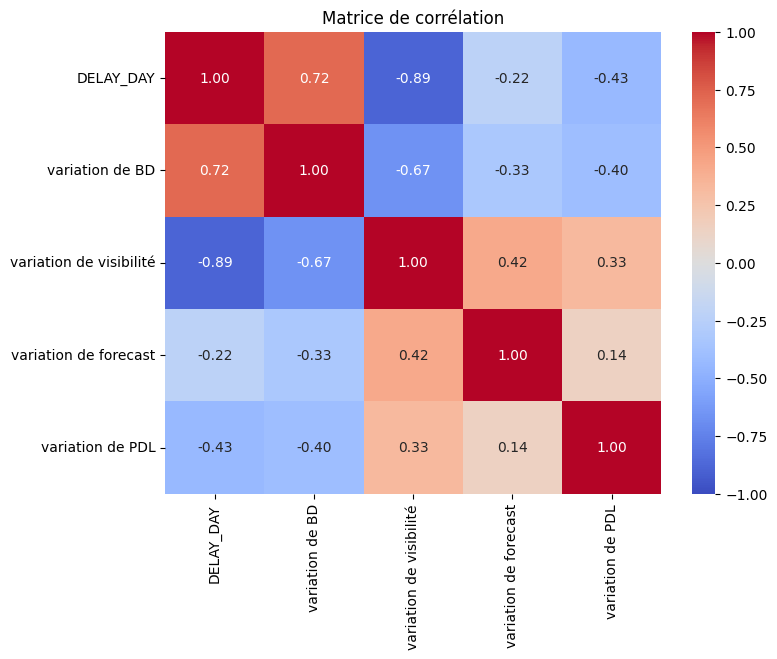

In [8]:
df_r_calculs = df_r[['DELAY_DAY','variation de BD', 'variation de visibilité', 'variation de forecast', 'variation de PDL']]

correlation = df_r_calculs.corr()

#représentation graphique de la matrice de corrélation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
plt.show()

Méthode statistique

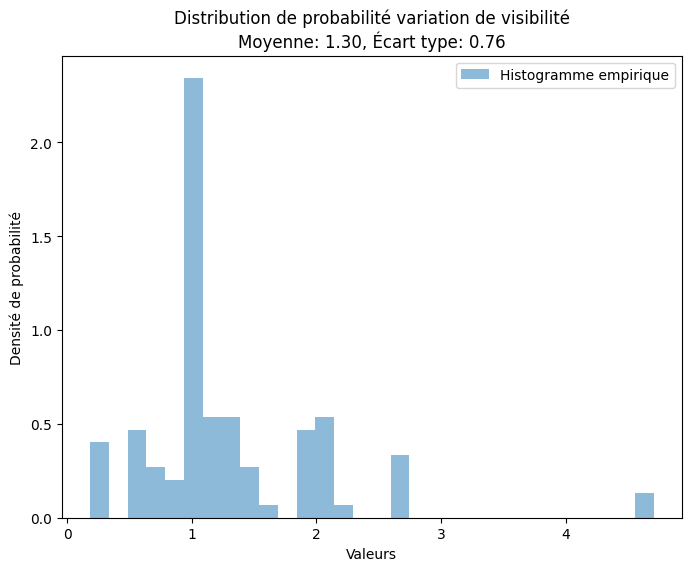

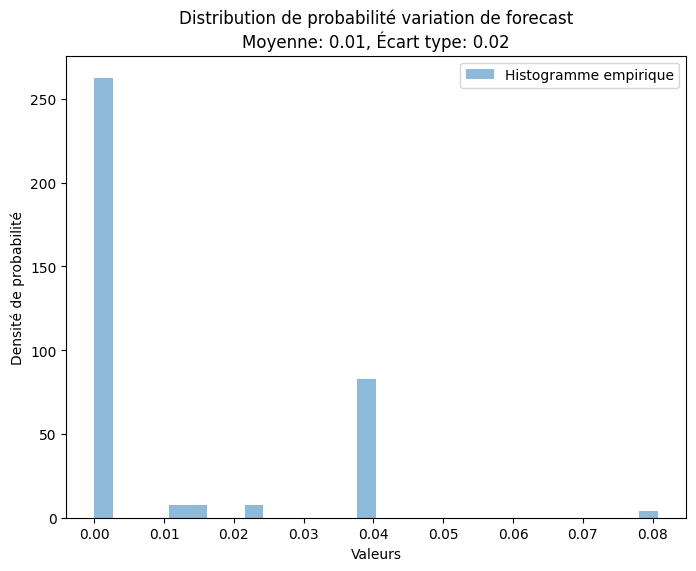

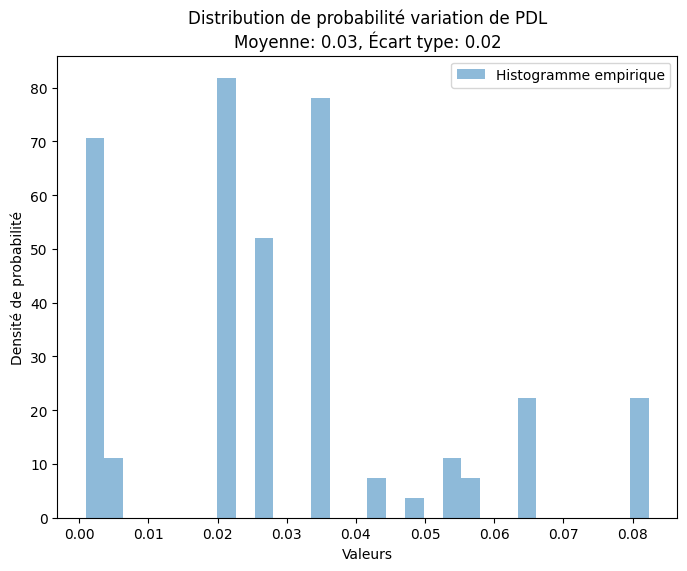

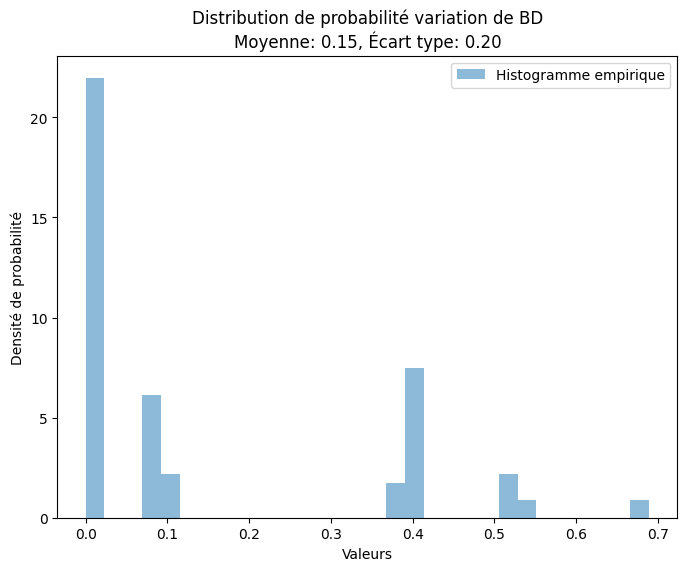

Moyenne de la visibilité: 1.2973783046656826
Écart-type de la visibilité: 0.760475554942928
Moyenne du forecast: 0.010709194849484415
Écart-type du forecast: 0.017586367371750698
Moyenne de PDL: 0.029178260786528645
Écart-type de PDL: 0.02170269048096683
Moyenne de BD: 0.15284012596947347
Écart-type de BD: 0.1993961387945261


In [10]:
from scipy.stats import gaussian_kde

# Charger les données à partir du fichier Excel
df_data = df_r.copy()

# Prendre la valeur absolue des valeurs de chaque colonne
df_data[['variation de visibilité', 'variation de forecast', 'variation de PDL', 'variation de BD']] = \
    df_data[['variation de visibilité', 'variation de forecast', 'variation de PDL', 'variation de BD']].abs()

# Fonction pour tracer les graphiques empiriques
def plot_distribution(column_name):
    data = df_data[column_name].values
    kde = gaussian_kde(data)
    x = np.linspace(min(data), max(data), 1000)
    #pdf_estimated = kde(x)
    mean_value = np.mean(data)
    std_value = np.std(data)
    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=30, density=True, alpha=0.5, label='Histogramme empirique')
    plt.title(f'Distribution de probabilité {column_name}\nMoyenne: {mean_value:.2f}, Écart type: {std_value:.2f}')
    plt.xlabel('Valeurs')
    plt.ylabel('Densité de probabilité')
    plt.legend()
    plt.show()
    return mean_value, std_value

# Récupérer les moyennes et écart-types
mean_value_visibilite, std_value_visibilite = plot_distribution('variation de visibilité')
mean_value_forecast, std_value_forecast = plot_distribution('variation de forecast')
mean_value_PDL, std_value_PDL = plot_distribution('variation de PDL')
mean_value_BD, std_value_BD = plot_distribution('variation de BD')

# Afficher les moyennes et les écart-types
print("Moyenne de la visibilité:", mean_value_visibilite)
print("Écart-type de la visibilité:", std_value_visibilite)
print("Moyenne du forecast:", mean_value_forecast)
print("Écart-type du forecast:", std_value_forecast)
print("Moyenne de PDL:", mean_value_PDL)
print("Écart-type de PDL:", std_value_PDL)
print("Moyenne de BD:", mean_value_BD)
print("Écart-type de BD:", std_value_BD)

# Enlever les lignes avec DELAY_DAY égal à 0
df_data = df_data[df_data['DELAY_DAY'] != 0]

# Fonction pour déterminer la cause du délai
def raison_delai(row):
    seuil_visibilite = mean_value_visibilite - std_value_visibilite
    seuil_forecast = mean_value_forecast
    seuil_PDL = mean_value_PDL - std_value_PDL
    seuil_BD = mean_value_BD - std_value_BD
    if row['variation de visibilité'] > seuil_visibilite:
        if row['variation de forecast'] > seuil_forecast:
            return 'forecast'
        elif row['variation de PDL'] > seuil_PDL:
            return 'PDL'
        elif row['variation de BD'] > seuil_BD:
            return 'BD'
        else:
            return 'visibilité'
    else:
        return 'FIFO'

# Créer une copie explicite du DataFrame
df_data_copy = df_data.copy()

# Appliquer la fonction raison_delai à chaque ligne du DataFrame
df_data_copy['Cause'] = df_data_copy.apply(lambda row: raison_delai(row), axis=1)

# Enregistrer le DataFrame modifié dans un fichier Excel
df_data_copy.to_excel('resultat_raison_stat.xlsx', index=False)

Choix optimal des paramètres

In [11]:
from sklearn.cluster import DBSCAN


#dimensions D in the data set, as minPts ≥ D + 1
from sklearn.metrics import silhouette_score

# Définir les colonnes pour l'analyse
colonnes_analyse = ['variation de forecast', 'variation de BD', 'variation de PDL']


df_r_calculs_sans_NA = df_r.dropna(subset=colonnes_analyse)

nombre_clusters_cible=4

meilleur_score = -1
meilleur_eps = None
meilleur_min_samples = None


for eps in np.arange(0.05, 0.45, 0.05):
  for min_samples in [4,5,6,7,8,9,10]:

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(df_r_calculs_sans_NA[colonnes_analyse])
    labels = dbscan.labels_

    nombre_clusters = len(set(labels))
    if nombre_clusters == nombre_clusters_cible:
        # Évaluer la qualité du clustering avec silhouette_score
        silhouette = silhouette_score(df_r_calculs_sans_NA[colonnes_analyse], labels, metric='euclidean', sample_size=None, random_state=None)
        # Mettre à jour les meilleurs paramètres si le score silhouette est meilleur
        if silhouette >= meilleur_score:
            meilleur_score = silhouette
            meilleur_eps = eps
            meilleur_min_samples = min_samples

#Réalisation du meilleur cas
dbscan = DBSCAN(eps=meilleur_eps, min_samples=meilleur_min_samples)
dbscan.fit(df_r_calculs_sans_NA[colonnes_analyse])

# Ajouter les labels de cluster au DataFrame
df_r['clusters'] = dbscan.labels_


Figure

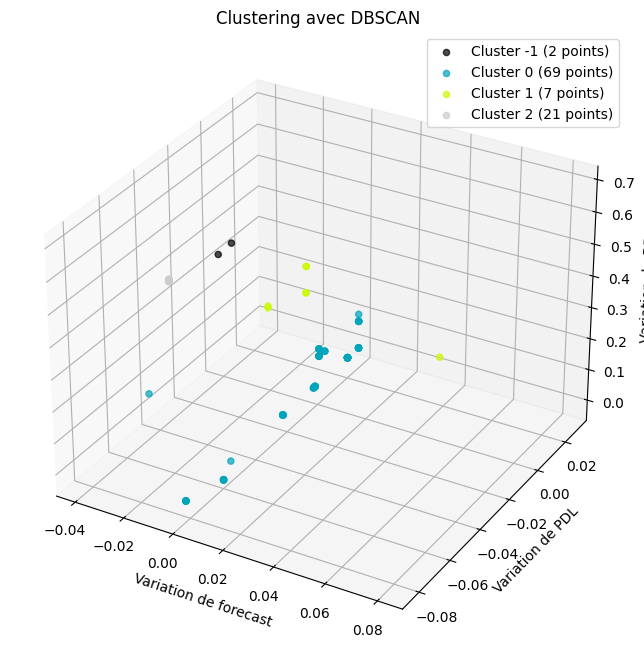

In [12]:
# Vérifier s'il y a des clusters attribués
if np.any(labels != -1):
    # Créer une nouvelle figure
    fig = plt.figure(figsize=(10, 8))

    # Créer une instance de la classe Axes3D
    ax = fig.add_subplot(111, projection='3d')

    # Définir les couleurs pour les clusters
    colors = [plt.cm.nipy_spectral(i) for i in np.linspace(0, 1, len(df_r['clusters'].unique()))]

    # Compter le nombre de points dans chaque cluster
    cluster_counts = df_r['clusters'].value_counts()

    # Afficher les résultats
    for i, cluster in enumerate(df_r['clusters'].unique()):
        cluster_data = df_r[df_r['clusters'] == cluster]
        ax.scatter(cluster_data['variation de forecast'], cluster_data['variation de PDL'], cluster_data['variation de BD'], color=colors[i], label=f'Cluster {cluster} ({cluster_counts[cluster]} points)', alpha=0.7)

    ax.set_xlabel('Variation de forecast')
    ax.set_ylabel('Variation de PDL')
    ax.set_zlabel('Variation de BD')
    ax.set_title('Clustering avec DBSCAN')
    ax.legend()

    plt.show()
else:
    print("Aucun cluster attribué par DBSCAN.")

Exportation sur Excel et attribution des raisons

In [13]:
resultats_tri=df_r[['ORDER_ID', 'variation de forecast', 'variation de BD', 'variation de PDL', 'clusters']]

autre=-1
PDL=0
BD=1
forecast=2


# Assigner
conditions = [
    (resultats_tri['clusters'] == PDL),
    (resultats_tri['clusters'] == BD),
    (resultats_tri['clusters'] == forecast),
    (resultats_tri['clusters'] == autre)
]
valeurs = ['PDL', 'BD', 'Forecast','Autre']

# Utiliser np.select pour attribuer les valeurs en fonction des conditions
resultats_tri['Facteur'] = np.select(conditions, valeurs, default='')

counts = resultats_tri['Facteur'].value_counts()

# Calculer le pourcentage d'apparition de chaque valeur
percentages = (counts / resultats_tri.shape[0]) * 100

# Afficher les résultats
print("Pourcentage d'apparition de chaque valeur dans la colonne 'facteur':")
print(percentages)

resultats_tri.to_excel('Resultats_clustering.xlsx', index=False)


Pourcentage d'apparition de chaque valeur dans la colonne 'facteur':
Facteur
PDL         69.696970
Forecast    21.212121
BD           7.070707
Autre        2.020202
Name: count, dtype: float64


<ipython-input-13-58562c12c586>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resultats_tri['Facteur'] = np.select(conditions, valeurs, default='')
